In [ ]:
import pandas as pd
df = pd.read_csv(r"/content/train.csv")
print(df.head())

   id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
0   0   F   0.550     0.430   0.150        0.7715          0.3285   
1   1   F   0.630     0.490   0.145        1.1300          0.4580   
2   2   I   0.160     0.110   0.025        0.0210          0.0055   
3   3   M   0.595     0.475   0.150        0.9145          0.3755   
4   4   I   0.555     0.425   0.130        0.7820          0.3695   

   Whole weight.2  Shell weight  Rings  
0          0.1465        0.2400     11  
1          0.2765        0.3200     11  
2          0.0030        0.0050      6  
3          0.2055        0.2500     10  
4          0.1600        0.1975      9  


In [ ]:
# shape of dataset:
df.shape

(90615, 10)

In [ ]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB


In [ ]:
# descriptive statistics
df.describe()

,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000
mean,45307.000000,0.517098,0.401679,0.135464,0.789035,0.340778,0.169422,0.225898,9.696794
std,26158.441658,0.118217,0.098026,0.038008,0.457671,0.204428,0.100909,0.130203,3.176221
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,22653.500000,0.445000,0.345000,0.110000,0.419000,0.177500,0.086500,0.120000,8.000000
50%,45307.000000,0.545000,0.425000,0.140000,0.799500,0.330000,0.166000,0.225000,9.000000
75%,67960.500000,0.600000,0.470000,0.160000,1.067500,0.463000,0.232500,0.305000,11.000000
max,90614.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [ ]:
# rename values
df = df.rename(columns={
        "Whole weight":"Total weight",
        "Whole weight.1":"Shucked weight",
        "Whole weight.2":"Viscera weight"
    })

In [ ]:
print("after renaming columns : ")
df.columns

after renaming columns : 


Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Total weight',
       'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')

In [ ]:
# drop id column
df = df.drop('id', axis=1)
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Total weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')

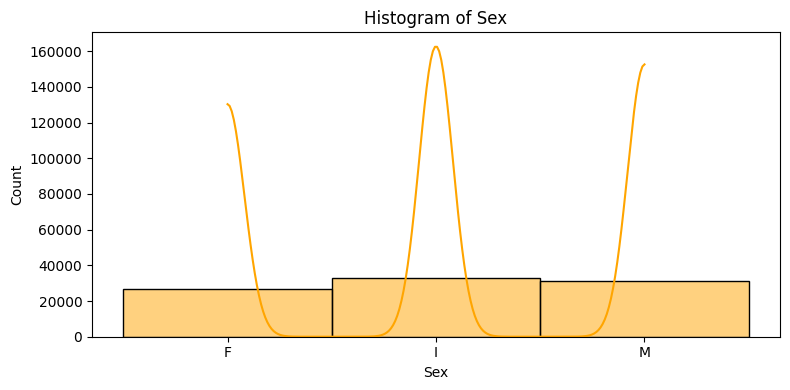

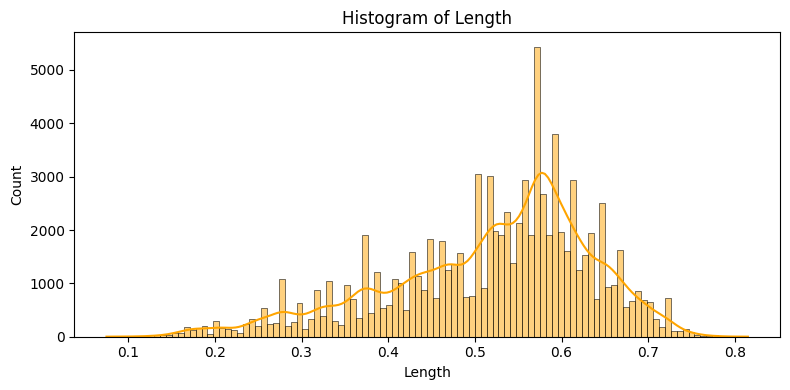

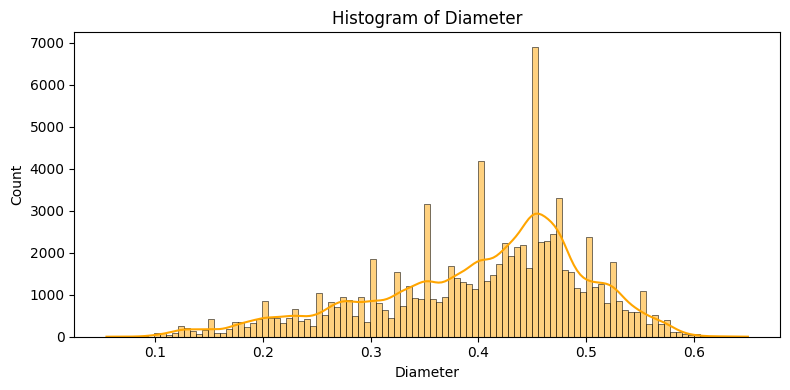

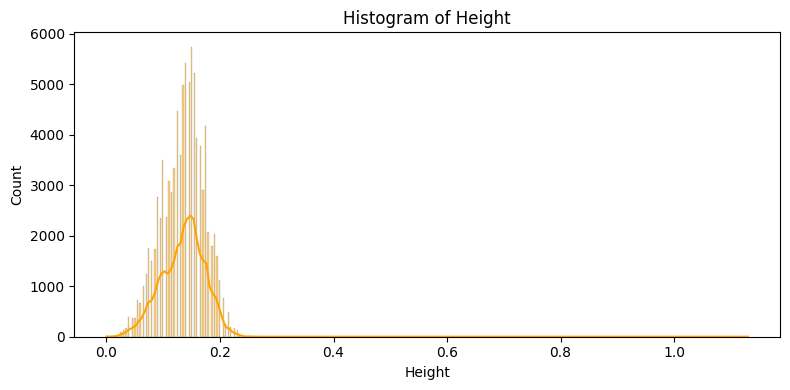

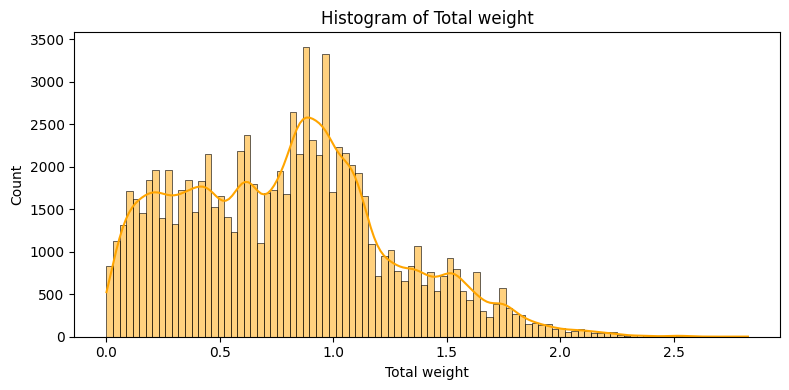

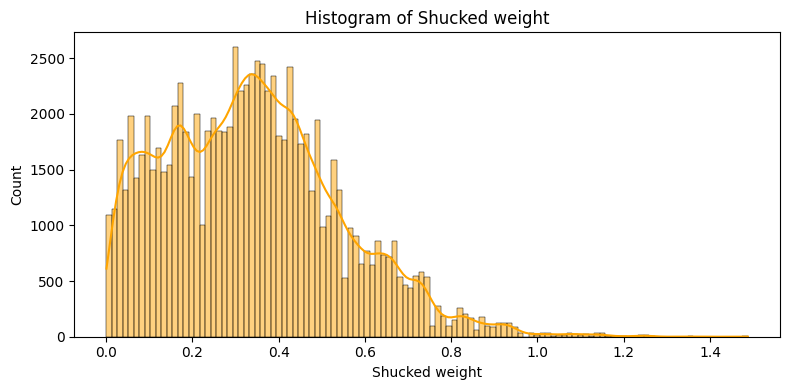

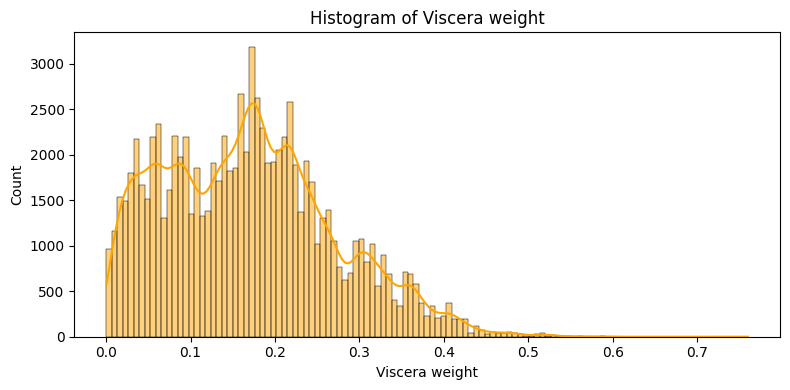

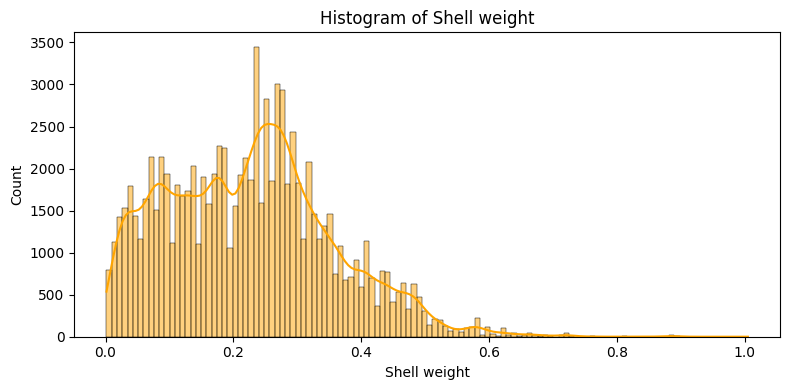

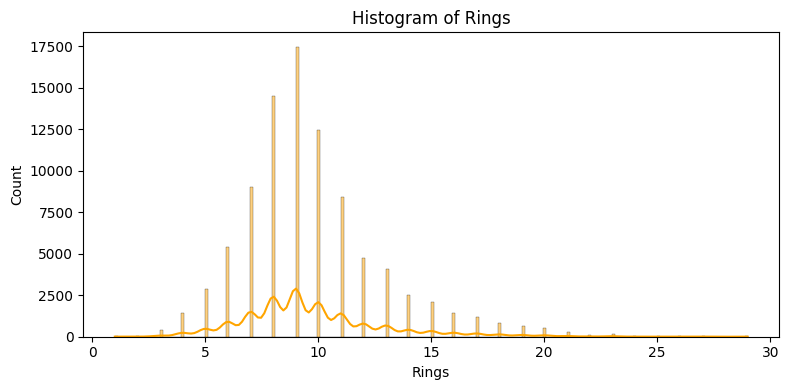

In [ ]:
# plot Histogram for each feature
import matplotlib.pyplot as plt
import seaborn as sns

for cols in df.columns:
  plt.figure(figsize=(8,4))
  sns.histplot(data=df, x=cols, kde=True, color='orange')
  plt.title(f"Histogram of {cols}")
  plt.tight_layout()
  plt.show()

In [ ]:
# encode the "sex" column using OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded_sex = encoder.fit_transform(df[['Sex']])

In [ ]:
# convert encoded column into dataframe
encoded_sex_df = pd.DataFrame(encoded_sex, columns=encoder.get_feature_names_out(['Sex']))
#concat the dataframes
data = pd.concat([df, encoded_sex_df], axis=1)
print(data.head())

   id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
0   0   F   0.550     0.430   0.150        0.7715          0.3285   
1   1   F   0.630     0.490   0.145        1.1300          0.4580   
2   2   I   0.160     0.110   0.025        0.0210          0.0055   
3   3   M   0.595     0.475   0.150        0.9145          0.3755   
4   4   I   0.555     0.425   0.130        0.7820          0.3695   

   Whole weight.2  Shell weight  Rings  Sex_F  Sex_I  Sex_M  
0          0.1465        0.2400     11    1.0    0.0    0.0  
1          0.2765        0.3200     11    1.0    0.0    0.0  
2          0.0030        0.0050      6    0.0    1.0    0.0  
3          0.2055        0.2500     10    0.0    0.0    1.0  
4          0.1600        0.1975      9    0.0    1.0    0.0  


In [ ]:
# drop Sex column
data = data.drop('Sex', axis=1)
print("after dropping: ")
data.columns

after dropping: 


Index(['id', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Rings', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

Text(0.5, 1.0, 'heatmap')

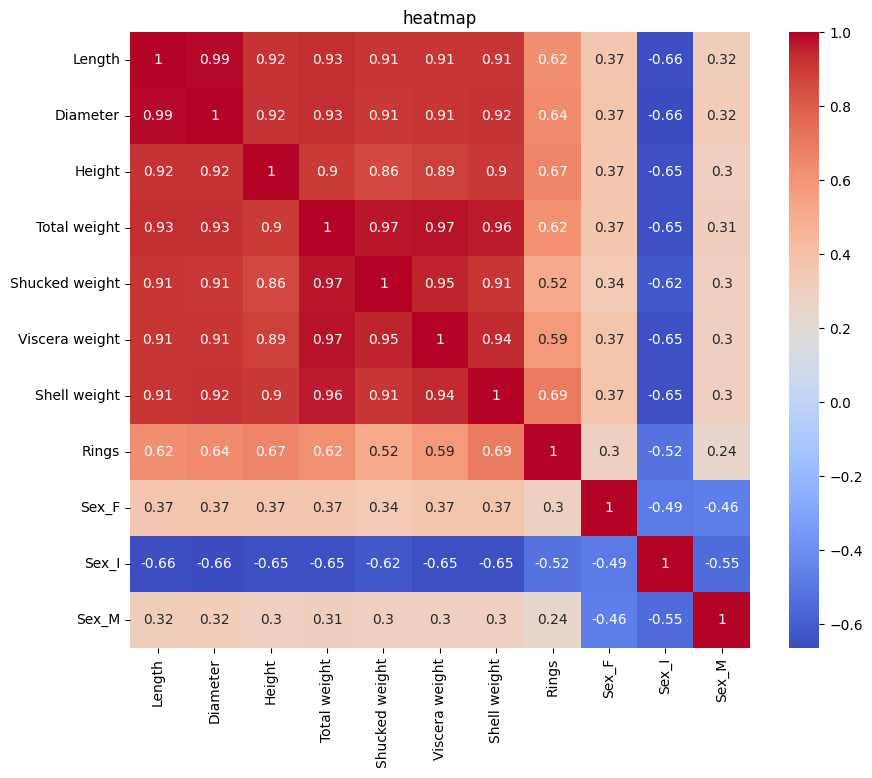

In [ ]:
# plot the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data=data.corr(), annot=True, cmap='coolwarm', cbar=True)
plt.title("heatmap")

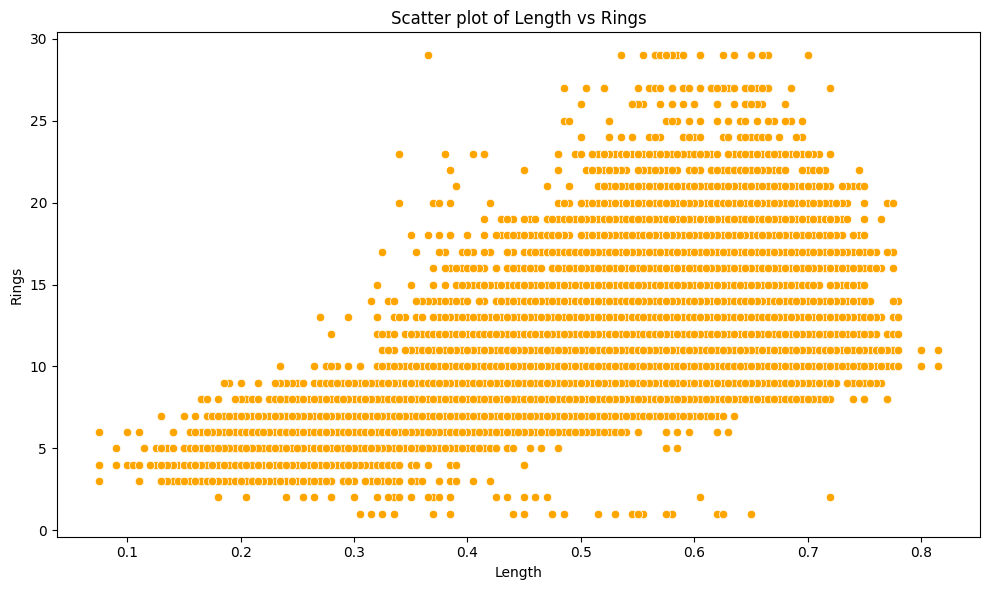

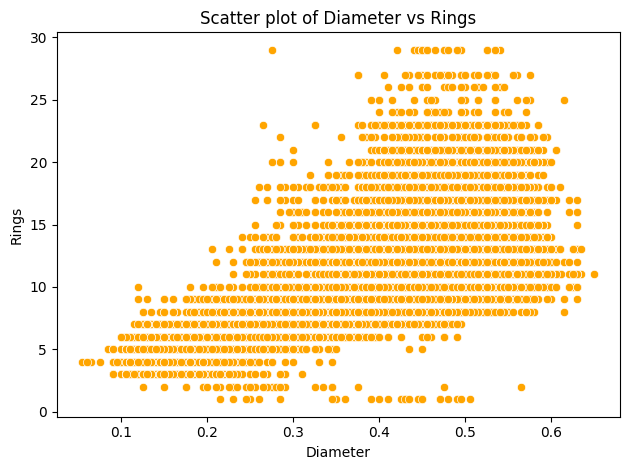

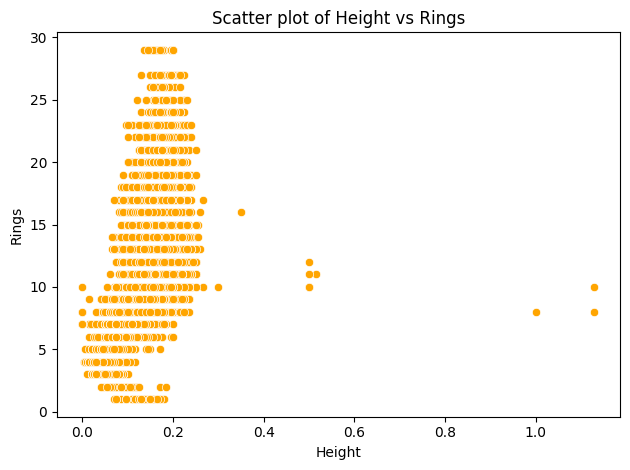

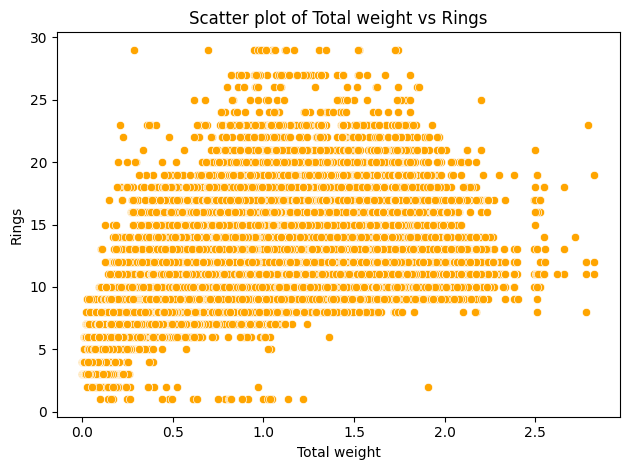

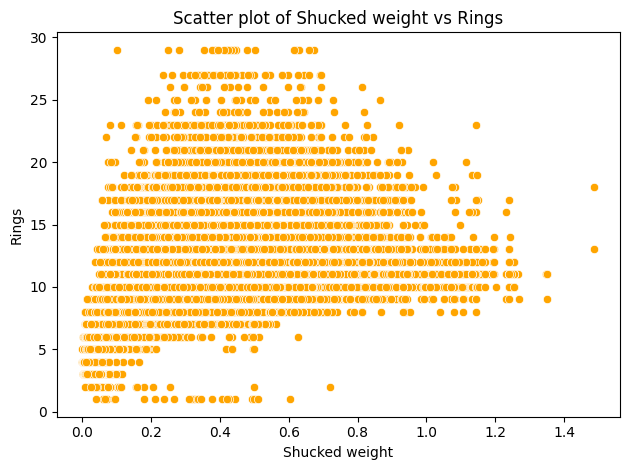

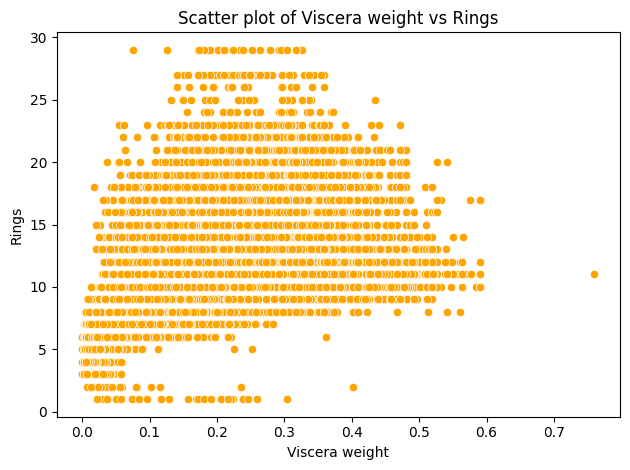

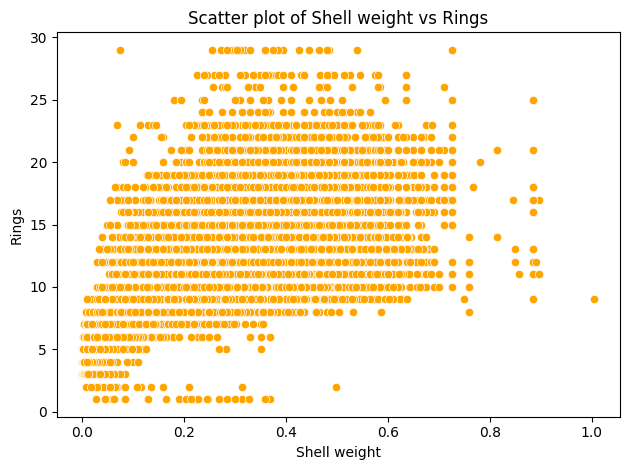

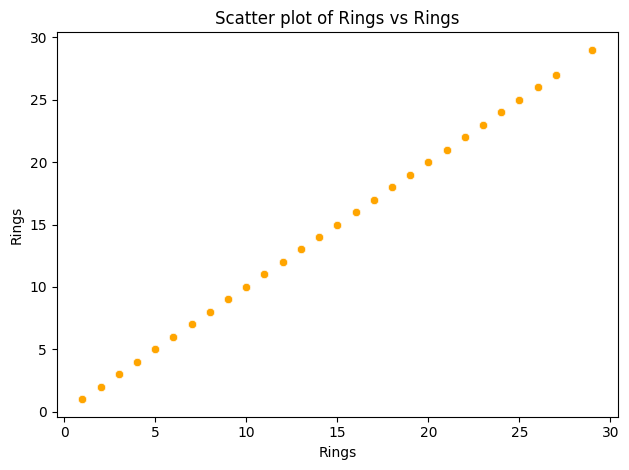

In [ ]:
# scatter plot
plt.figure(figsize=(10,6))
for cols in df.columns:
  if df[cols].dtype == 'object':
    continue
  sns.scatterplot(data=data, x=cols, y='Rings', color='orange')
  plt.title(f"Scatter plot of {cols} vs Rings")
  plt.tight_layout()
  plt.show()

In [ ]:
# null values
print("null values = ", data.isnull().sum())
print("total null values = ", data.isnull().sum().sum())

null values =  id                0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
Sex_F             0
Sex_I             0
Sex_M             0
dtype: int64
total null values =  0


In [ ]:
# duplicated values
print("total duplicate values = ", data.duplicated().sum())

total duplicate values =  0


In [ ]:
num_cols = []
for cols in df.columns:
  if df[cols].dtypes == 'int' or df[cols].dtypes == 'float':
    num_cols.append(cols)
print(num_cols)

['id', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings']


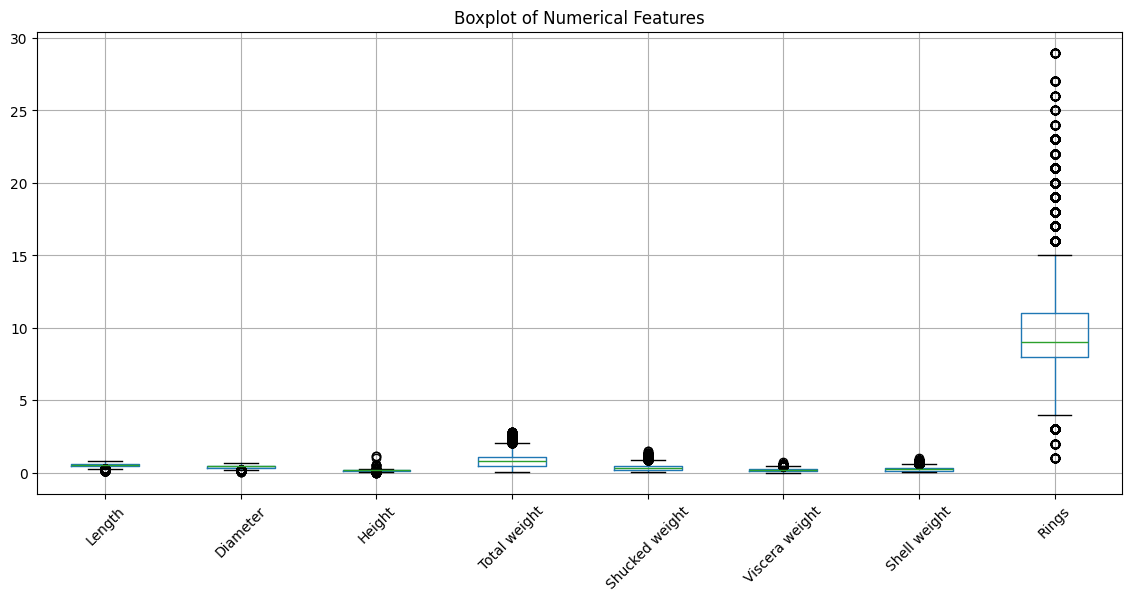

In [ ]:
plt.figure(figsize=(14, 6))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [ ]:
def detect_outliers(data_frame, column):
  q1 = data[column].quantile(0.25)
  q3 = data[column].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr
  outliers = data_frame[(data[column] < lower) | (data[column] > upper)]
  return outliers

In [ ]:
print("number of outliers: ")
total_outliers = 0
for cols in data.columns:
  outliers = detect_outliers(data, cols)
  total_outliers += len(outliers)
  print(f"Column {cols}: {len(outliers)}")
print("total outliers = ", total_outliers)
print(f"percetange of outliers = {(total_outliers * 100) / (data.shape[0] * data.shape[1]):.2f} %")

number of outliers: 
Column id: 0
Column Length: 1460
Column Diameter: 1580
Column Height: 348
Column Whole weight: 574
Column Whole weight.1: 967
Column Whole weight.2: 440
Column Shell weight: 671
Column Rings: 5725
Column Sex_F: 0
Column Sex_I: 0
Column Sex_M: 0
total outliers =  11765
percetange of outliers = 1.08 %


In [ ]:
# log transformation
import numpy as np
for cols in num_cols:
  data[cols] = np.log1p(data[cols])

In [ ]:
data.columns

Index(['id', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Rings', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X = data.drop('Rings', axis=1)
y = data['Rings']

print("X length = ", X.shape[0])
print("y length = ", y.shape[0])

X length =  90615
y length =  90615


In [ ]:
print(X.columns)

Index(['id', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')


In [ ]:
print("null values in X: ", X.isnull().sum())
print("\n null values in y: ", y.isnull().sum())

null values in X:  id                0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Sex_F             0
Sex_I             0
Sex_M             0
dtype: int64

 null values in y:  0


In [ ]:
X.columns

Index(['id', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

In [ ]:
X = X.drop('id', axis=1)
X.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

In [ ]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

In [ ]:
# function to evaluate model
def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  return mse, r2

In [ ]:
# train the Decision tree model with hyperparameter tuning
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=2, min_samples_leaf=1)
dt_model.fit(X_train, y_train)
# evaluate model
dt_mse, dt_r2 = evaluate_model(dt_model, X_test, y_test)
print("Decision Tree Model:")
print("MSE: ", dt_mse)
print("R2 Score: ", dt_r2)


Decision Tree Model:
MSE:  0.027117774664348678
R2 Score:  0.6728930389366305


In [ ]:
# train randomforest regressor with hyperparameter tuning
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=1)
rf_model.fit(X_train, y_train)
# evaluate
rf_mse, rf_r2 = evaluate_model(rf_model, X_test, y_test)
print("Random Forest Model:")
print("MSE: ", rf_mse)
print("R2 Score: ", rf_r2)

Random Forest Model:
MSE:  0.026355706946202265
R2 Score:  0.682085447181511


In [ ]:
# train XGBoostRegressor with hyperparameter tuning
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)
# evaluate
xgb_mse, xgb_r2 = evaluate_model(xgb_model, X_test, y_test)
print("XGBoost Model:")
print("MSE: ", xgb_mse)
print("R2 Score: ", xgb_r2)

XGBoost Model:
MSE:  0.023248348179758724
R2 Score:  0.7195678252750669


In [ ]:
from sklearn.metrics import root_mean_squared_log_error
model_names = ['dt_model','rf_model','xgb_model']
for names in model_names:
  print(f"{names} | rmsle = {root_mean_squared_log_error(y_test, eval(names).predict(X_test))}")

dt_model | rmsle = 0.04928738256517648
rf_model | rmsle = 0.048605862134700015
xgb_model | rmsle = 0.046006552693583856


In [ ]:
# load test dataset
test_df = pd.read_csv(r"/content/test.csv")
print(test_df.head())

      id Sex  Length  Diameter  Height  Whole weight  Whole weight.1  \
0  90615   M   0.645     0.475   0.155        1.2380          0.6185   
1  90616   M   0.580     0.460   0.160        0.9830          0.4785   
2  90617   M   0.560     0.420   0.140        0.8395          0.3525   
3  90618   M   0.570     0.490   0.145        0.8740          0.3525   
4  90619   I   0.415     0.325   0.110        0.3580          0.1575   

   Whole weight.2  Shell weight  
0          0.3125        0.3005  
1          0.2195        0.2750  
2          0.1845        0.2405  
3          0.1865        0.2350  
4          0.0670        0.1050  


In [ ]:
# Load test dataset again to ensure 'id' column is present
test_df = pd.read_csv(r"/content/test.csv")

# Save the 'id' column before it's dropped
test_ids = test_df['id']

# rename columns
test_df = test_df.rename(columns={
        "Whole weight":"Total weight",
        "Whole weight.1":"Shucked weight",
        "Whole weight.2":"Viscera weight"
    })
print(test_df.columns)

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Total weight',
       'Shucked weight', 'Viscera weight', 'Shell weight'],
      dtype='object')


In [ ]:
# null values
print("null values = ", test_df.isnull().sum())
print("total null values = ", test_df.isnull().sum().sum())


null values =  id                0
Sex               0
Length            0
Diameter          0
Height            0
Total weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
dtype: int64
total null values =  0


In [ ]:
# drop id
test_df = test_df.drop(columns=['id'], axis=1)
test_df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Total weight', 'Shucked weight',
       'Viscera weight', 'Shell weight'],
      dtype='object')

In [ ]:
# encode "sex" column
encoded_sex = encoder.transform(test_df[['Sex']])
# convert to dataframe
encoded_sex_df = pd.DataFrame(encoded_sex, columns=encoder.get_feature_names_out(['Sex']))
print(encoded_sex_df.head())

   Sex_F  Sex_I  Sex_M
0    0.0    0.0    1.0
1    0.0    0.0    1.0
2    0.0    0.0    1.0
3    0.0    0.0    1.0
4    0.0    1.0    0.0


In [ ]:
# concate the dataframes
test_data = pd.concat([test_df, encoded_sex_df], axis=1)
print(test_data.head())

  Sex  Length  Diameter  Height  Total weight  Shucked weight  Viscera weight  \
0   M   0.645     0.475   0.155        1.2380          0.6185          0.3125   
1   M   0.580     0.460   0.160        0.9830          0.4785          0.2195   
2   M   0.560     0.420   0.140        0.8395          0.3525          0.1845   
3   M   0.570     0.490   0.145        0.8740          0.3525          0.1865   
4   I   0.415     0.325   0.110        0.3580          0.1575          0.0670   

   Shell weight  Sex_F  Sex_I  Sex_M  
0        0.3005    0.0    0.0    1.0  
1        0.2750    0.0    0.0    1.0  
2        0.2405    0.0    0.0    1.0  
3        0.2350    0.0    0.0    1.0  
4        0.1050    0.0    1.0    0.0  


In [ ]:
# drop "Sex" column
test_data = test_data.drop(columns=['Sex'], axis=1)
print(test_data.columns)

Index(['Length', 'Diameter', 'Height', 'Total weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')


In [ ]:
X_train.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

In [ ]:
test_data = test_data.rename(
    columns={
        'Total weight':'Whole weight',
        'Shucked weight':'Whole weight.1',
        'Viscera weight':'Whole weight.2'
    }
)
test_data.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

In [ ]:
# create submission file "id" and "Rings"
submission_df = pd.DataFrame({
    'id': test_ids, # Use the saved 'id' column
    'Rings': xgb_model.predict(test_data)
})

In [ ]:
submission_df = pd.DataFrame({
    'id': test_ids, # Use the saved 'id' column
    'Rings': dt_model.predict(test_data)
})

submission_df.to_csv("submission_4.csv", index=False)

In [ ]:
# save the submission file
submission_df.to_csv('submission_1.csv', index=False)

In [ ]:
copy_df = data.copy()
copy_df.columns

Index(['id', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Rings', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

In [ ]:
copy_df = copy_df.drop('id',axis=1)
copy_df.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1',
       'Whole weight.2', 'Shell weight', 'Rings', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

scale_features = [
    "Length", "Diameter", "Height",
    "Whole weight", "Whole weight.1",
    "Whole weight.2", "Shell weight"
]

scaler = StandardScaler()
copy_df[scale_features]=scaler.fit_transform(copy_df[scale_features])

In [ ]:
copy_df.head()

,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings,Sex_F,Sex_I,Sex_M
0,0.304917,0.312807,0.396699,0.089425,0.014040,-0.189468,0.161888,2.484907,1.0,0.0,0.0
1,0.927699,0.883007,0.266542,0.802384,0.635852,1.071465,0.758141,2.484907,1.0,0.0,0.0
2,-3.281847,-3.201402,-3.040558,-2.042325,-1.848188,-1.759272,-1.842050,1.945910,0.0,1.0,0.0
3,0.659080,0.742639,0.396699,0.389741,0.246458,0.399634,0.238490,2.397895,0.0,0.0,1.0
4,0.344772,0.264215,-0.127370,0.112287,0.217234,-0.052041,-0.170716,2.302585,0.0,1.0,0.0


In [ ]:
print("Mean of training data:", scaler.mean_)
print("Std dev of training data:", scaler.scale_)

Mean of training data: [0.4136156  0.33512641 0.1264816  0.5487108  0.28195026 0.15285295
 0.19813657]
Std dev of training data: [0.08080681 0.07208292 0.03347707 0.25849376 0.14958726 0.0851815
 0.10485546]


In [ ]:
X_new = copy_df.drop('Rings', axis=1)
y_new = copy_df['Rings']

In [ ]:
# split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [ ]:
# train linear regressor model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_new, y_train_new)
# evalueate model
lr_mse, lr_r2 = evaluate_model(lr_model, X_test_new, y_test_new)
print("Linear Regression Model:")
print("MSE: ", lr_mse)
print("R2 Score: ", lr_r2)

Linear Regression Model:
MSE:  0.026703802058591648
R2 Score:  0.6778865652384289


In [ ]:
submission_df = pd.DataFrame({
    'id': test_ids, # Use the saved 'id' column
    'Rings': lr_model.predict(test_data)
})

submission_df.to_csv("submission_2.csv", index=False)

In [ ]:
# create second XGB model
rf_model_2 = RandomForestRegressor(n_estimators=100, max_depth=5,min_samples_split=2, min_samples_leaf=1)
rf_model_2.fit(X_train_new, y_train_new)
# evaluate model
rf_mse_2, rf_r2_2 = evaluate_model(rf_model_2, X_test_new, y_test_new)
print(f"mse = {rf_mse_2}")
print(f'r2 = {rf_r2_2}')

mse = 0.026451840930107832
r2 = 0.6809258352399159


In [ ]:
submission_df = pd.DataFrame({
    'id': test_ids, # Use the saved 'id' column
    'Rings': rf_model_2.predict(test_data)
})

submission_df.to_csv("submission_3.csv", index=False)